# Exploratory Data Analysis (EDA) - AirIQ Project
This notebook contains the Day 2 exploratory data analysis for the AirIQ air quality dashboard. 
We will clean, analyze, and visualize the 2025 hourly air quality data across 14 stations in Bengaluru, 
as well as inspect the associated ERA5 weather data.

In [4]:
pip install matplotlib

  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/75/77/5acecfe672ba0fa1b8c0454f69ce155d1e6fc5852fa7206bf9afaf767121/matplotlib-3.10.9-cp310-cp310-win_amd64.whl.metadata
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ---------------------------------------- 52.8/52.8 kB 1.4 MB/s eta 0:00:00
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/54/ec/5162b8582f2c994721018d0c9ece9dc6ff769d298a8ac6b6a652c307e7df/contourpy-1.3.2-cp310-cp310-win_amd64.whl.metadata
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Obtaining dependency information for cycler>=0.10 from https://files.pythonhosted.org/packages/e7/05/c19819d5e3d95294a6f5947fb9b9629efb316b96de511b418c53d245aae6/cycler-0.12.1-py3-none-any.whl.metadata
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Obtaining dependency information for fonttools>=4.22.0 from https://f


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# Section 1: Load all 14 CSVs and Concatenate
import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt

# Define data directory path
data_dir = os.path.join("..", "data")
csv_files = glob.glob(os.path.join(data_dir, "Raw_data_1Hr_2025_site_*.csv"))

all_dfs = []

print(f"Found {len(csv_files)} station files. Loading data...")

for file_path in csv_files:
    filename = os.path.basename(file_path)
    
    # Extract station name using regex (grabs text between site_XXXX_ and _Bengaluru)
    match = re.search(r'site_\d+_(.*?)_Bengaluru', filename)
    if match:
        station_name = match.group(1).replace('_', ' ')
    else:
        station_name = filename # Fallback
        
    # Read CSV, treating 'NA' strings as missing values
    df = pd.read_csv(file_path, na_values=['NA'])
    
    # Inject the station name as a feature
    df['station_name'] = station_name
    all_dfs.append(df)

# Concatenate into a single master DataFrame
aq_df = pd.concat(all_dfs, ignore_index=True)

# Ensure Timestamp is treated as datetime for proper handling later
aq_df['Timestamp'] = pd.to_datetime(aq_df['Timestamp'])

print("All files successfully loaded and concatenated!")

Found 14 station files. Loading data...
All files successfully loaded and concatenated!


## Section 2: Combined DataFrame Shape
Let's check the size and scope of our unified dataset.

## Section 3: Date Range Check
Validating that the temporal data accurately covers the full year of 2025.

In [6]:
print(f"Combined DataFrame Shape: {aq_df.shape}")
print(f"Total rows: {aq_df.shape[0]:,}")
print(f"Total columns: {aq_df.shape[1]}")

Combined DataFrame Shape: (116808, 21)
Total rows: 116,808
Total columns: 21


In [7]:
min_time = aq_df['Timestamp'].min()
max_time = aq_df['Timestamp'].max()

print(f"Data starts on: {min_time}")
print(f"Data ends on:   {max_time}")
print(f"Temporal span:  {max_time - min_time}")

Data starts on: 2025-01-01 00:00:00
Data ends on:   2025-12-31 23:00:00
Temporal span:  364 days 23:00:00


## Section 4: Missing Value Analysis per Station
Analyzing the percentage of missing values (`NaN`) for core criteria parameters across each unique station.

In [8]:
# Target columns for pollutant validation
target_pollutants = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)', 'CO (mg/m³)']

# Compute missing percentage per station
missing_pct = aq_df.groupby('station_name')[target_pollutants].apply(lambda x: (x.isna().mean() * 100).round(2))

print("Percentage of Missing Values per Station:")
display(missing_pct)

Percentage of Missing Values per Station:


,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),CO (mg/m³)
station_name,,,,,
BTM Layout,4.21,8.08,14.68,5.53,3.87
BWSSB Kadabesanahalli,52.08,45.49,43.24,56.90,42.59
Bapuji Nagar,17.44,16.92,15.38,15.56,19.59
City Railway Station,100.00,18.57,18.37,18.54,18.84
Hebbal,6.55,2.42,10.54,3.81,23.74
Hombegowda Nagar,3.25,2.55,2.32,1.99,2.05
Jayanagar 5th Block,7.13,7.63,20.67,11.45,10.27
Jigani,6.82,6.46,3.77,2.79,2.57
Kasturi Nagar,13.07,10.49,13.78,13.23,8.95


## Section 5: PM2.5 Descriptive Statistics per Station
Reviewing baseline profiles (min, max, mean, standard deviation) across the city network.

In [9]:
pm25_stats = aq_df.groupby('station_name')['PM2.5 (µg/m³)'].agg(['min', 'max', 'mean', 'std']).round(2)
print("PM2.5 Descriptive Statistics by Station:")
display(pm25_stats)

PM2.5 Descriptive Statistics by Station:


,min,max,mean,std
station_name,,,,
BTM Layout,0.58,116.96,25.24,12.65
BWSSB Kadabesanahalli,4.57,160.36,50.35,27.39
Bapuji Nagar,1.00,421.00,28.91,17.50
City Railway Station,NaN,NaN,NaN,NaN
Hebbal,1.00,276.75,26.22,23.90
Hombegowda Nagar,1.00,162.75,19.45,15.26
Jayanagar 5th Block,1.00,794.00,30.21,30.12
Jigani,0.66,910.32,37.36,43.35
Kasturi Nagar,11.35,985.07,31.15,18.70


## Section 6: Load and Inspect ERA5 Weather Data
Loading the downloaded ERA5 surface level weather matrix to confirm structure and dimensions.

In [10]:
weather_path = os.path.join(data_dir, "raw", "bengaluru_weather_raw.csv")

if os.path.exists(weather_path):
    weather_df = pd.read_csv(weather_path)
    print(f"Weather DataFrame Shape: {weather_df.shape}")
    print("\nColumns available:")
    print(weather_df.columns.tolist())
    print("\nFirst 3 rows of weather data:")
    display(weather_df.head(3))
else:
    print(f"Error: Weather data file not found at {weather_path}")

Weather DataFrame Shape: (8760, 9)

Columns available:
['valid_time', 'u100', 'v100', 'u10', 'v10', 'd2m', 't2m', 'latitude', 'longitude']

First 3 rows of weather data:


,valid_time,u100,v100,u10,v10,d2m,t2m,latitude,longitude
0,2025-01-01 00:00:00,-5.900940,-3.487015,-2.606339,-1.730606,288.73367,291.52734,13.0,77.5
1,2025-01-01 01:00:00,-6.025421,-3.097626,-2.650177,-1.445312,288.57794,291.59650,13.0,77.5
2,2025-01-01 02:00:00,-6.109177,-2.530045,-3.165939,-1.375092,288.40080,291.97464,13.0,77.5


## Section 7: Hourly PM2.5 Pattern: Peenya vs Jayanagar
Visualizing systemic diurnal fluctuations by comparing industrial zones vs residential baseline metrics.

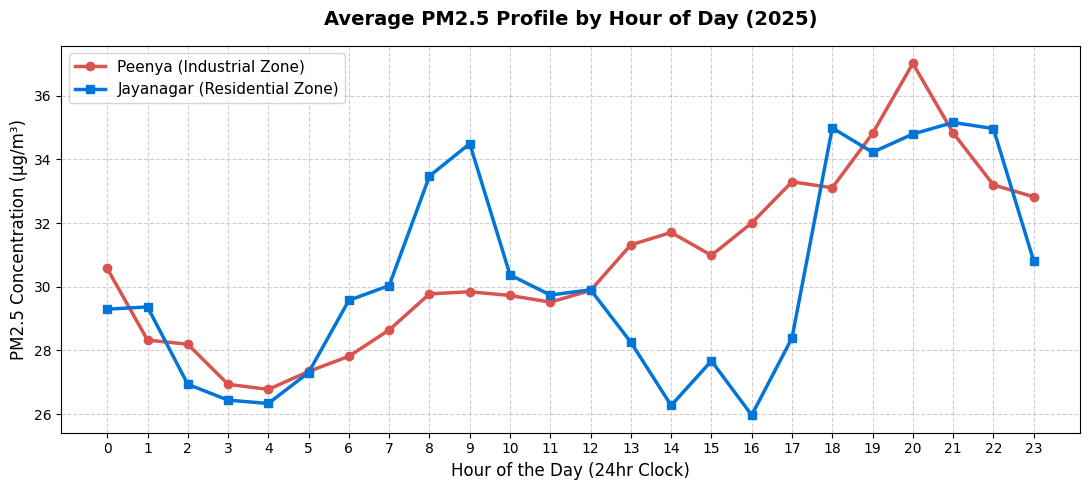

In [11]:
# Extract hour of day to create profiles
aq_df['Hour'] = aq_df['Timestamp'].dt.hour

# Isolate Peenya and Jayanagar variants
peenya_mask = aq_df['station_name'].str.contains('Peenya', case=False)
jayanagar_mask = aq_df['station_name'].str.contains('Jayanagar', case=False)

peenya_hourly = aq_df[peenya_mask].groupby('Hour')['PM2.5 (µg/m³)'].mean()
jayanagar_hourly = aq_df[jayanagar_mask].groupby('Hour')['PM2.5 (µg/m³)'].mean()

# Render Comparative Visualization
plt.figure(figsize=(11, 5))
plt.plot(peenya_hourly.index, peenya_hourly.values, label='Peenya (Industrial Zone)', color='#d9534f', linewidth=2.5, marker='o')
plt.plot(jayanagar_hourly.index, jayanagar_hourly.values, label='Jayanagar (Residential Zone)', color='#0275d8', linewidth=2.5, marker='s')

plt.title('Average PM2.5 Profile by Hour of Day (2025)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hour of the Day (24hr Clock)', fontsize=12)
plt.ylabel('PM2.5 Concentration (µg/m³)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()

# Save visual asset for frontend/reference tracking
os.makedirs(os.path.join("..", "charts"), exist_ok=True)
plt.savefig(os.path.join("..", "charts", "hourly_pm25_comparison.png"), dpi=150)
plt.show()

## Section 8: PM2.5 Completeness Summary (> 85%)
Filtering stations that maintain reliable structural coverage to prioritize operational training models tomorrow.

In [12]:
# Calculate structural completeness percentages
completeness_series = aq_df.groupby('station_name')['PM2.5 (µg/m³)'].apply(lambda x: (x.notna().mean() * 100))

print("=== STATIONS WITH > 85% PM2.5 COMPLETENESS (RECOMMENDED FOR MODELING) ===")
viable_stations = completeness_series[completeness_series > 85]

if not viable_stations.empty:
    for idx, (station, score) in enumerate(viable_stations.items(), 1):
        print(f"{idx}. {station} ({score:.2f}% Complete)")
else:
    print("Warning: No stations meet the > 85% data criteria threshold.")
    
print("\n=== STATIONS TO CRITICALLY MONITOR OR EXCLUDE ===")
low_data_stations = completeness_series[completeness_series <= 85]
for station, score in low_data_stations.items():
    print(f"⚠️ {station} - Only {score:.2f}% data present")

=== STATIONS WITH > 85% PM2.5 COMPLETENESS (RECOMMENDED FOR MODELING) ===
1. BTM Layout (95.79% Complete)
2. Hebbal (93.45% Complete)
3. Hombegowda Nagar (96.75% Complete)
4. Jayanagar 5th Block (92.87% Complete)
5. Jigani (93.18% Complete)
6. Kasturi Nagar (86.93% Complete)
7. Peenya (93.93% Complete)
8. Silk Board (88.48% Complete)

=== STATIONS TO CRITICALLY MONITOR OR EXCLUDE ===
⚠️ BWSSB Kadabesanahalli - Only 47.92% data present
⚠️ Bapuji Nagar - Only 82.56% data present
⚠️ City Railway Station - Only 0.00% data present
⚠️ RVCE-Mailasandra - Only 71.97% data present
⚠️ Sanegurava Halli - Only 0.00% data present
⚠️ Shivapura Peenya - Only 75.10% data present
